In [92]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries loaded successfully!


In [93]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'is_gesture'

WINDOW_SIZE_SAMPLES = 60
WINDOW_STRIDE_SAMPLES = 20
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [94]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        rtParent.title AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' or smt.group_id is null THEN 'no' ELSE 'yes' END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    LEFT JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    LEFT JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien' and rtParent.title != 'Tap and Hold'
),

no_gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        'No Gesture' AS gesture,
        'No Gesture' AS parent_gesture,
        s.participant_id,
        'no' AS is_gesture,
        NULL  AS group_id -- TODO : Assign group_id
    FROM sensorData sd
    LEFT JOIN gesture_samples gs 
      ON gs.id = sd.id -- Check if this row was already labeled as a gesture
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    
    -- Exclude rows that were found in gesture_samples (gs.id IS NULL)
    -- Also keep your original session_task_id and 'Szenarien' filters
    WHERE gs.id IS NULL
      AND sd.session_task_id IN (
          SELECT DISTINCT session_task_id FROM preciseMarker
      )
      AND rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
-- UNION ALL
-- SELECT * FROM no_gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [95]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [96]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")
df_raw["is_gesture"] = df_raw["is_gesture"].astype("category")

In [97]:
def augment_data_all_permutations(df, limit=None):
    augmented_dfs = []

    # All 5! = 120 permutations of touch indices 1..5
    permutations = list(itertools.permutations(range(1, 6)))
    # randomly shuffle the permutations, in case there is a limit set
    if limit is not None:
        np.random.shuffle(permutations)

    for i, perm in enumerate(permutations):
        if limit is not None and i >= limit:
            break

        df_aug = df.copy()

        # Reorder touch columns according to permutation
        for j, new_idx in enumerate(perm, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']

        # Append unique suffix to id fields
        suffix = f'_perm{i}'
        df_aug['id'] = df_aug['id'].astype(str) + suffix
        df_aug['group_id'] = df_aug['group_id'].astype(str) + suffix
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + suffix
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + suffix

        augmented_dfs.append(df_aug)

    # Original + all permutations
    return pd.concat([df] + augmented_dfs, ignore_index=True)

In [98]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [99]:
df_raw[LABEL_COLUMN].value_counts()

is_gesture
no     310877
yes     40725
Name: count, dtype: int64

In [100]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [101]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    42500
6331fbd1-76bb-48d6-92a2-80a55a70d134    33519
696b4743-9d39-4fb1-8271-90e7d48652af    23710
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    60844
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    44355
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    44334
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    51999
fdd02af8-c764-43ba-8247-c612f85568b4    50341
dtype: int64

In [102]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel',
 'group_id']

In [103]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

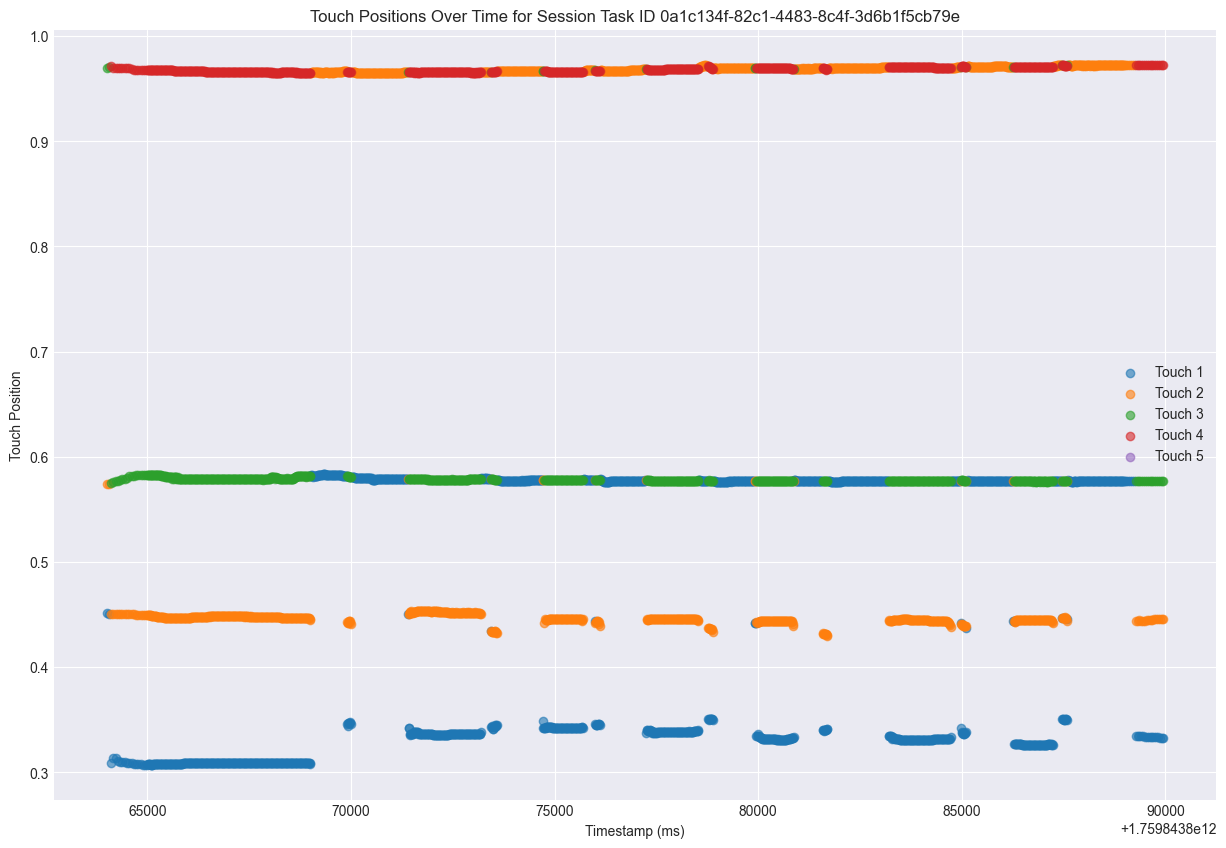

In [104]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_raw["session_task_id"].unique()[0]
session_df = df_raw[df_raw["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [105]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


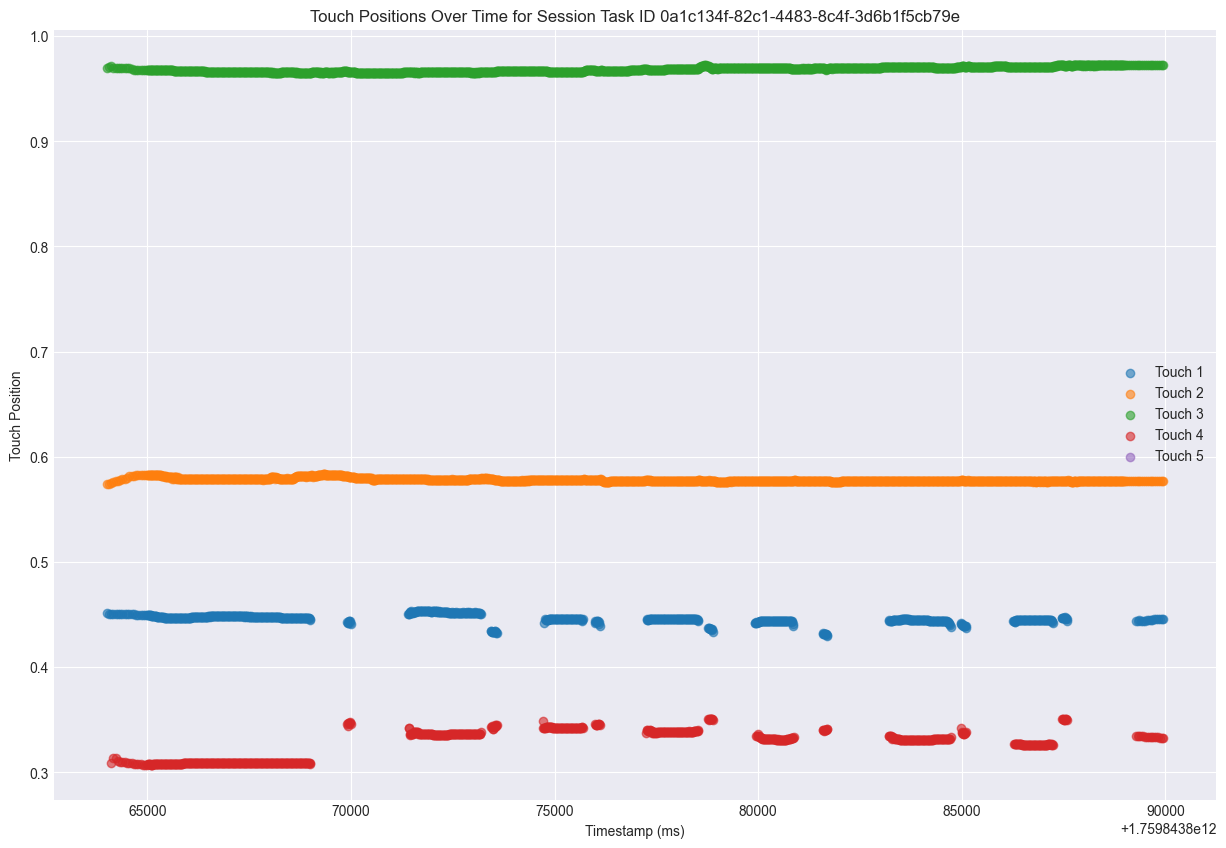

In [106]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_clean["session_task_id"].unique()[0]
session_df = df_clean[df_clean["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [107]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position         0
touch_1_pressure         0
touch_1_channel          0
touch_2_position         0
touch_2_pressure         0
touch_2_channel          0
touch_3_position         0
touch_3_pressure         0
touch_3_channel          0
touch_4_position         0
touch_4_pressure         0
touch_4_channel          0
touch_5_position         0
touch_5_pressure         0
touch_5_channel          0
group_id            284911
dtype: int64

In [108]:
# Print the LABEL_COLUMN counts
print(df_clean[LABEL_COLUMN].value_counts())

is_gesture
no     310877
yes     40725
Name: count, dtype: int64


In [109]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=5, long_smoothing_window=20):
    # Create empty feature dataframe
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    # Button Press Features
    add_feature("button_pressed_mean", feature_df["button_pressed"].rolling(window=smoothing_window, min_periods=1).mean())
    add_feature("button_pressed_std", feature_df["button_pressed"].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
    add_feature("button_pressed_diff", feature_df["button_pressed"].diff().fillna(0))

    # Motor Angle Features
    add_feature("motor_angle_mean", feature_df["motor_angle"].rolling(window=smoothing_window, min_periods=1).mean())
    add_feature("motor_angle_std", feature_df["motor_angle"].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
    add_feature("motor_angle_diff", feature_df["motor_angle"].diff().fillna(0))
    
    # Instant Features
    pressure_cols = [f"touch_{i+1}_pressure" for i in range(5)]
    active_touches = (feature_df[pressure_cols] > 0)
    add_feature("num_active_touches", active_touches.sum(axis=1))

    # Distances for each finger in the rolling window to each other finger
    for (i, j) in combinations(range(1, 6), 2):
        pos_i = feature_df[f'touch_{i}_position']
        pos_j = feature_df[f'touch_{j}_position']
        pres_i = feature_df[f'touch_{i}_pressure']
        pres_j = feature_df[f'touch_{j}_pressure']

        # distance only when both fingers are active; else 0 (or np.nan if you prefer)
        dist_col = f"dist_{i}_{j}"
        dist = short_dist(pos_i, pos_j)
        add_feature(dist_col, dist)
        add_feature(f"{dist_col}_mean", dist.rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f"{dist_col}_std", dist.rolling(window=smoothing_window, min_periods=1).std().fillna(0))

        both_active = (pres_i > 0) & (pres_j > 0)
        add_feature(f"{dist_col}_both_active", dist.where(both_active).fillna(0))
        add_feature(f"{dist_col}_both_active_mean", dist.where(both_active).rolling(window=smoothing_window, min_periods=1).mean().fillna(0))


    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        add_feature(f'{position_col}_mean', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{pressure_col}_mean', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        # add_feature(f'{channel_col}_mean', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        # add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        
        add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        # add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))

        pressure_rising_edge = (feature_df[pressure_col].diff() > 0) & (feature_df[pressure_col] > 0)
        add_feature(f'{pressure_col}_rising_edge', pressure_rising_edge.astype(int))

    return feature_df, additional_features

In [110]:
def get_column_names(feature_columns):
    return feature_columns
    # return SENSOR_COLUMNS
    # return SENSOR_COLUMNS + feature_columns

In [111]:
is_null = df_clean["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
df_clean["group_id"] = df_clean["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [112]:
# df_clean = augment_data_all_permutations(df_clean, limit=20)

In [113]:
# get the max sample size, grouped by group_id where is_gesture == 'yes'
max_gesture_size = df_clean[df_clean[LABEL_COLUMN] == 'yes'].groupby('group_id').size().max()
max_gesture_size

np.int64(215)

In [114]:
df, additional_columns = create_feature_df(df_clean)
feature_columns = get_column_names(additional_columns)

df = df.sort_values(
    by=["participant_id", "session_task_id", TIMESTAMP_COLUMN]
).reset_index(drop=True)

gesture_block = 0
prev_pid = None
prev_sid = None
prev_is_gesture = None
blocks = []
prev_group_id = None

for i, row in df.iterrows():
    pid = row["participant_id"]
    sid = row["session_task_id"]
    is_g = row["is_gesture"]
    group_id = row["group_id"]

    # New block when:
    # - participant or session changes
    # - or gesture/background state changes
    # - or gesture label changes
    # - or group_id changes
    # - or the gesture_block is currently longer than max_gesture_size
    current_block_size = blocks.count(gesture_block)
    if (
        pid != prev_pid or
        sid != prev_sid or
        is_g != prev_is_gesture or
        group_id != prev_group_id or
        current_block_size >= max_gesture_size
    ):
        gesture_block += 1

    blocks.append(gesture_block)

    prev_pid = pid
    prev_sid = sid
    prev_is_gesture = is_g
    prev_group_id = group_id

df["gesture_block"] = blocks

In [115]:
# Check how many gesture_blocks there are with 10 or less samples
block_sizes = df.groupby("gesture_block").size()
small_blocks = block_sizes[block_sizes <= 10]
print(f"Number of gesture blocks with 10 or less samples: {len(small_blocks)}")

# Remove them
df = df[~df["gesture_block"].isin(small_blocks.index)].reset_index(drop=True)

Number of gesture blocks with 10 or less samples: 226


In [116]:
df.head()

,id,session_task_id,session_task_row_index,timestamp,timestamp_ms,button_pressed,motor_angle,gesture,parent_gesture,participant_id,is_gesture,group_id,estimated_timestamp,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,active_ids,button_pressed_mean,button_pressed_std,button_pressed_diff,motor_angle_mean,motor_angle_std,motor_angle_diff,num_active_touches,dist_1_2,dist_1_2_mean,dist_1_2_std,dist_1_2_both_active,dist_1_2_both_active_mean,dist_1_3,dist_1_3_mean,dist_1_3_std,dist_1_3_both_active,dist_1_3_both_active_mean,dist_1_4,dist_1_4_mean,dist_1_4_std,dist_1_4_both_active,dist_1_4_both_active_mean,dist_1_5,dist_1_5_mean,dist_1_5_std,dist_1_5_both_active,dist_1_5_both_active_mean,dist_2_3,dist_2_3_mean,dist_2_3_std,dist_2_3_both_active,dist_2_3_both_active_mean,dist_2_4,dist_2_4_mean,dist_2_4_std,dist_2_4_both_active,dist_2_4_both_active_mean,dist_2_5,dist_2_5_mean,dist_2_5_std,dist_2_5_both_active,dist_2_5_both_active_mean,dist_3_4,dist_3_4_mean,dist_3_4_std,dist_3_4_both_active,dist_3_4_both_active_mean,dist_3_5,dist_3_5_mean,dist_3_5_std,dist_3_5_both_active,dist_3_5_both_active_mean,dist_4_5,dist_4_5_mean,dist_4_5_std,dist_4_5_both_active,dist_4_5_both_active_mean,touch_1_position_mean,touch_1_pressure_mean,touch_1_position_diff,touch_1_pressure_diff,touch_1_position_rollstd,touch_1_pressure_rollstd,touch_1_pressure_rising_edge,touch_2_position_mean,touch_2_pressure_mean,touch_2_position_diff,touch_2_pressure_diff,touch_2_position_rollstd,touch_2_pressure_rollstd,touch_2_pressure_rising_edge,touch_3_position_mean,touch_3_pressure_mean,touch_3_position_diff,touch_3_pressure_diff,touch_3_position_rollstd,touch_3_pressure_rollstd,touch_3_pressure_rising_edge,touch_4_position_mean,touch_4_pressure_mean,touch_4_position_diff,touch_4_pressure_diff,touch_4_position_rollstd,touch_4_pressure_rollstd,touch_4_pressure_rising_edge,touch_5_position_mean,touch_5_pressure_mean,touch_5_position_diff,touch_5_pressure_diff,touch_5_position_rollstd,touch_5_pressure_rollstd,touch_5_pressure_rising_edge,gesture_block
0,29dea9a1-8bd2-4505-927a-f3cecc0b2d61,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,0,2025-10-07 13:31:04,1759843864000,0,0.996954,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,no,no_gesture_block_1,2025-10-07 13:31:04.000000000,0.451703,0.216837,0.4,0.573659,0.201484,0.333333,0.969923,0.055165,0.166667,0.000000,0.000000,0.0,0.0,0.0,0.0,"[0, 1, 2]",0.0,0.0,0.0,0.996954,0.000000,0.000000,3,0.121955,0.121955,0.000000,0.121955,0.121955,0.518219,0.518219,0.000000,0.518219,0.518219,0.451703,0.451703,0.000000,0.000000,0.000000,0.451703,0.451703,0.000000,0.0,0.0,0.396264,0.396264,0.000000,0.396264,0.396264,0.573659,0.573659,0.000000,0.000000,0.000000,0.573659,0.573659,0.000000,0.0,0.0,0.969923,0.969923,0.000000,0.000000,0.000000,0.969923,0.969923,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.451703,0.216837,0.000000,0.000000,0.000000,0.000000,0,0.573659,0.201484,0.000000,0.000000,0.000000,0.000000,0,0.969923,0.055165,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
1,c19a249e-bd05-458e-9169-79c9587dc713,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,1,2025-10-07 13:31:04,1759843864055,0,0.996964,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,no,no_gesture_block_1,2025-10-07 13:31:04.055555556,0.450245,0.244898,0.6,0.573914,0.218182,0.333333,0.971091,0.327984,0.333333,0.000000,0.000000,0.0,0.0,0.0,0.0,"[0, 1, 2]",0.0,0.0,0.0,0.996959,0.000007,0.000010,3,0.123668,0.122812,0.001211,0.123668,0.122812,0.520846,0.519533,0.001857,0.520846,0.519533,0.450245,0.450974,0.001031,0.000000,0.000000,0.450245,0.450974,0.001031,0.0,0.0,0.397178,0.396721,0.000646,0.397178,0.396721,0.573914,0.573786,0.000180,0.000000,0.000000,0.57391

In [117]:
# Print the amount of unique gesture blocks
print("Unique gesture blocks:", df["gesture_block"].nunique())
# Print the min, max and average block length
block_lengths = df.groupby("gesture_block").size()
print("Block length stats - min:", block_lengths.min(), "max:", block_lengths.max(), "mean:", block_lengths.mean())

Unique gesture blocks: 3055
Block length stats - min: 11 max: 215 mean: 114.87004909983634


                                     id                       session_task_id  \
0  29dea9a1-8bd2-4505-927a-f3cecc0b2d61  0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e   
1  c19a249e-bd05-458e-9169-79c9587dc713  0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e   
2  6e68f5ce-3ef2-4249-971e-7c6b37ac7515  0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e   
3  49433ca0-231b-40d2-9598-7cc2a88d5f0c  0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e   
4  3cd1421a-4bf9-4408-961d-3b1ca20dbdfd  0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e   

   session_task_row_index           timestamp   timestamp_ms  button_pressed  \
0                       0 2025-10-07 13:31:04  1759843864000               0   
1                       1 2025-10-07 13:31:04  1759843864055               0   
2                       2 2025-10-07 13:31:04  1759843864111               0   
3                       3 2025-10-07 13:31:04  1759843864166               0   
4                       4 2025-10-07 13:31:04  1759843864222               0   

   motor_angle                  

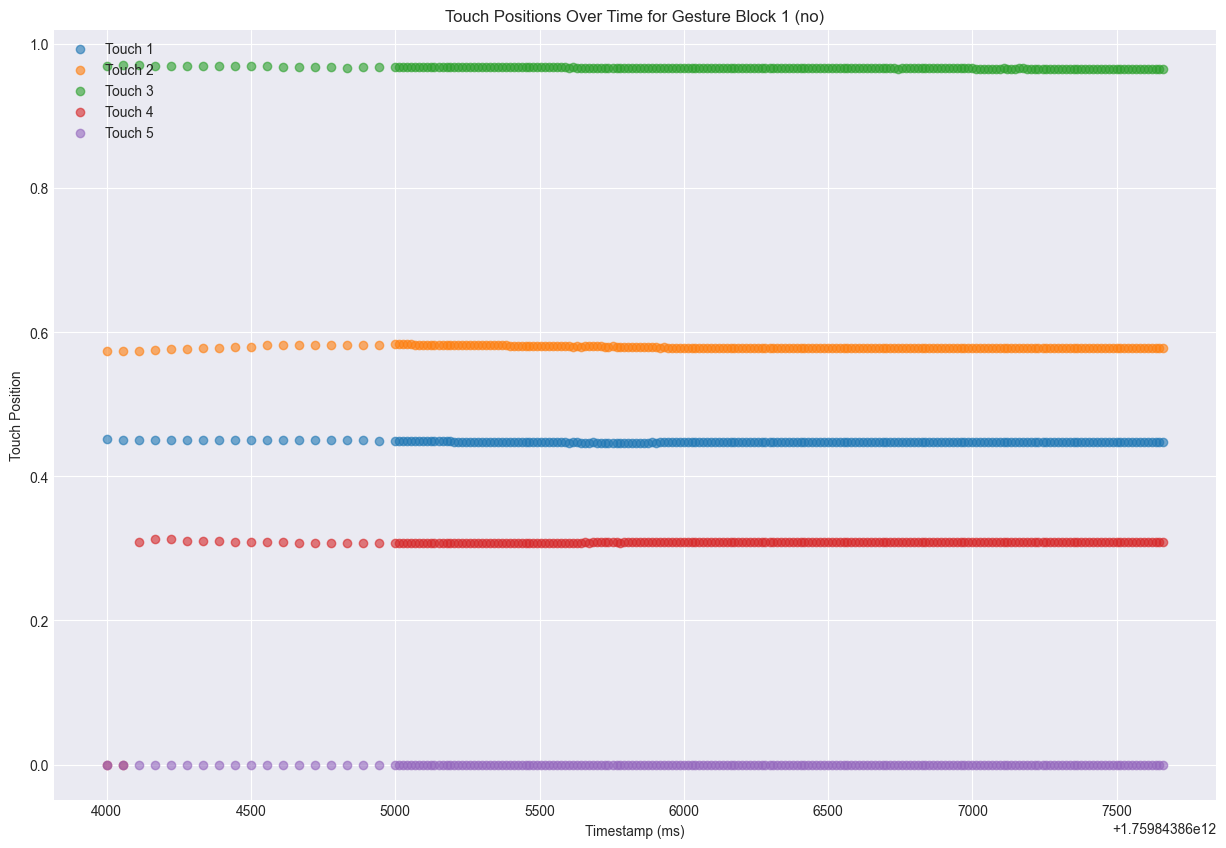

In [118]:
# draw a graph of the finger positions for the first gesture_block and title it with the parent_gesture

# get the index of the unique gesture block that is a "Tap and Hold" gesture
idx_tap_and_hold = np.where(df["gesture_block"].unique() == df[df[LABEL_COLUMN] == "no"]["gesture_block"].iloc[0])[0][0]

plt.figure(figsize=(15, 10))
first_gesture_block = df["gesture_block"].unique()[idx_tap_and_hold]
gesture_block_df = df[df["gesture_block"] == first_gesture_block]
print(gesture_block_df.head())
for touch_num in range(1, 6):
    plt.scatter(
        gesture_block_df["timestamp_ms"], 
        gesture_block_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Gesture Block {first_gesture_block} ({gesture_block_df[LABEL_COLUMN].iloc[0]})")
plt.legend()
plt.show()

In [119]:
# Print unique "gesture" column counts
print(df["is_gesture"].value_counts())

is_gesture
no     310421
yes     40507
Name: count, dtype: int64


In [120]:
gesture_blocks = (
    # df[df["is_gesture"] != 'semi']
    df
    .groupby(["participant_id", "session_task_id", "gesture_block", "group_id"])
)
print(f"Total gesture blocks (excluding 'No Gesture'): {len(gesture_blocks)}")

Total gesture blocks (excluding 'No Gesture'): 3055


In [121]:
sequences = []   # list of arrays, each (T_i, D)
labels = []      # list of strings or ints
meta = []

for (pid, sid, gb, group_id), gdf in gesture_blocks:
    # Extract feature matrix for this gesture
    X_seq = gdf[feature_columns].to_numpy(dtype="float32")  # shape (T_i, D)
    if len(X_seq) == 0:
        continue

    sequences.append(X_seq)
    labels.append(gdf[LABEL_COLUMN].iloc[0])  # all rows in block share the same label
    meta.append({
        "participant_id": pid,
        "session_task_id": sid,
        "gesture_block": gb,
        "group_id": group_id,
        "num_samples": len(X_seq),
    })

In [122]:
# Print the number of sequences and unique labels
print(f"Extracted {len(sequences)} sequences with {len(set(labels))} unique labels.")
# Print the unique labels and their counts
label_counts = pd.Series(labels).value_counts()
print("Label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Extracted 3055 sequences with 2 unique labels.
Label counts:
  no: 2176
  yes: 879


In [123]:
feature_columns

['button_pressed_mean',
 'button_pressed_std',
 'button_pressed_diff',
 'motor_angle_mean',
 'motor_angle_std',
 'motor_angle_diff',
 'num_active_touches',
 'dist_1_2',
 'dist_1_2_mean',
 'dist_1_2_std',
 'dist_1_2_both_active',
 'dist_1_2_both_active_mean',
 'dist_1_3',
 'dist_1_3_mean',
 'dist_1_3_std',
 'dist_1_3_both_active',
 'dist_1_3_both_active_mean',
 'dist_1_4',
 'dist_1_4_mean',
 'dist_1_4_std',
 'dist_1_4_both_active',
 'dist_1_4_both_active_mean',
 'dist_1_5',
 'dist_1_5_mean',
 'dist_1_5_std',
 'dist_1_5_both_active',
 'dist_1_5_both_active_mean',
 'dist_2_3',
 'dist_2_3_mean',
 'dist_2_3_std',
 'dist_2_3_both_active',
 'dist_2_3_both_active_mean',
 'dist_2_4',
 'dist_2_4_mean',
 'dist_2_4_std',
 'dist_2_4_both_active',
 'dist_2_4_both_active_mean',
 'dist_2_5',
 'dist_2_5_mean',
 'dist_2_5_std',
 'dist_2_5_both_active',
 'dist_2_5_both_active_mean',
 'dist_3_4',
 'dist_3_4_mean',
 'dist_3_4_std',
 'dist_3_4_both_active',
 'dist_3_4_both_active_mean',
 'dist_3_5',
 'dist_

In [124]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(labels)           # shape (N,)
num_classes = len(le.classes_)
y = to_categorical(y_int, num_classes)     # shape (N, num_classes)


In [125]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(seq.shape[0] for seq in sequences)  # e.g. 400
D = sequences[0].shape[1]

print(max_len)

X_padded = pad_sequences(
    sequences,
    maxlen=max_len,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0      # padding value
)  # shape: (N, max_len, D)
X = X_padded


215


In [126]:
unique_participants = df['participant_id'].unique()
print(f"Unique participants: {len(unique_participants)}")

amount_of_participants = len(unique_participants)
amount_of_val_participants = max(1, int(0.2 * amount_of_participants))
amount_of_test_participants = max(1, int(0.2 * amount_of_participants))

val_participants = np.random.choice(unique_participants, size=amount_of_val_participants, replace=False)
remaining_participants = [p for p in unique_participants if p not in val_participants]
test_participants = np.random.choice(remaining_participants, size=amount_of_test_participants, replace=False)
train_participants = [p for p in remaining_participants if p not in test_participants]

print(f"Train participants: {train_participants}")
print(f"Validation participants: {val_participants}")
print(f"Test participants: {test_participants}")

Unique participants: 8
Train participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733', '696b4743-9d39-4fb1-8271-90e7d48652af', '6a1b56e6-47ce-43cb-96cb-713d055d8f6d', '707c3867-fe15-4b05-bf7b-fc5f3b501fb1', '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0', 'fdd02af8-c764-43ba-8247-c612f85568b4']
Validation participants: ['6331fbd1-76bb-48d6-92a2-80a55a70d134']
Test participants: ['d3b39f0f-b799-4d69-b7a3-a663e5c7438f']


In [127]:
# Split participants into train, val, test sets
train_indices = df['participant_id'].isin(train_participants)
val_indices = df['participant_id'].isin(val_participants)
test_indices = df['participant_id'].isin(test_participants)

# Map each sequence back to its participant_id
sequence_participants = []
gesture_block_keys = list(gesture_blocks.groups.keys())
for (pid, sid, gb, group_id) in gesture_block_keys:
    sequence_participants.append(pid)
sequence_participants = np.array(sequence_participants)
# Now create boolean masks for sequences
train_seq_indices = np.isin(sequence_participants, train_participants)
val_seq_indices = np.isin(sequence_participants, val_participants)
test_seq_indices = np.isin(sequence_participants, test_participants)

X_train, y_train = X[train_seq_indices], y[train_seq_indices]
X_val, y_val = X[val_seq_indices], y[val_seq_indices]
X_test, y_test = X[test_seq_indices], y[test_seq_indices]
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (2304, 215, 92), (2304, 2)
Validation set: (337, 215, 92), (337, 2)
Test set: (414, 215, 92), (414, 2)


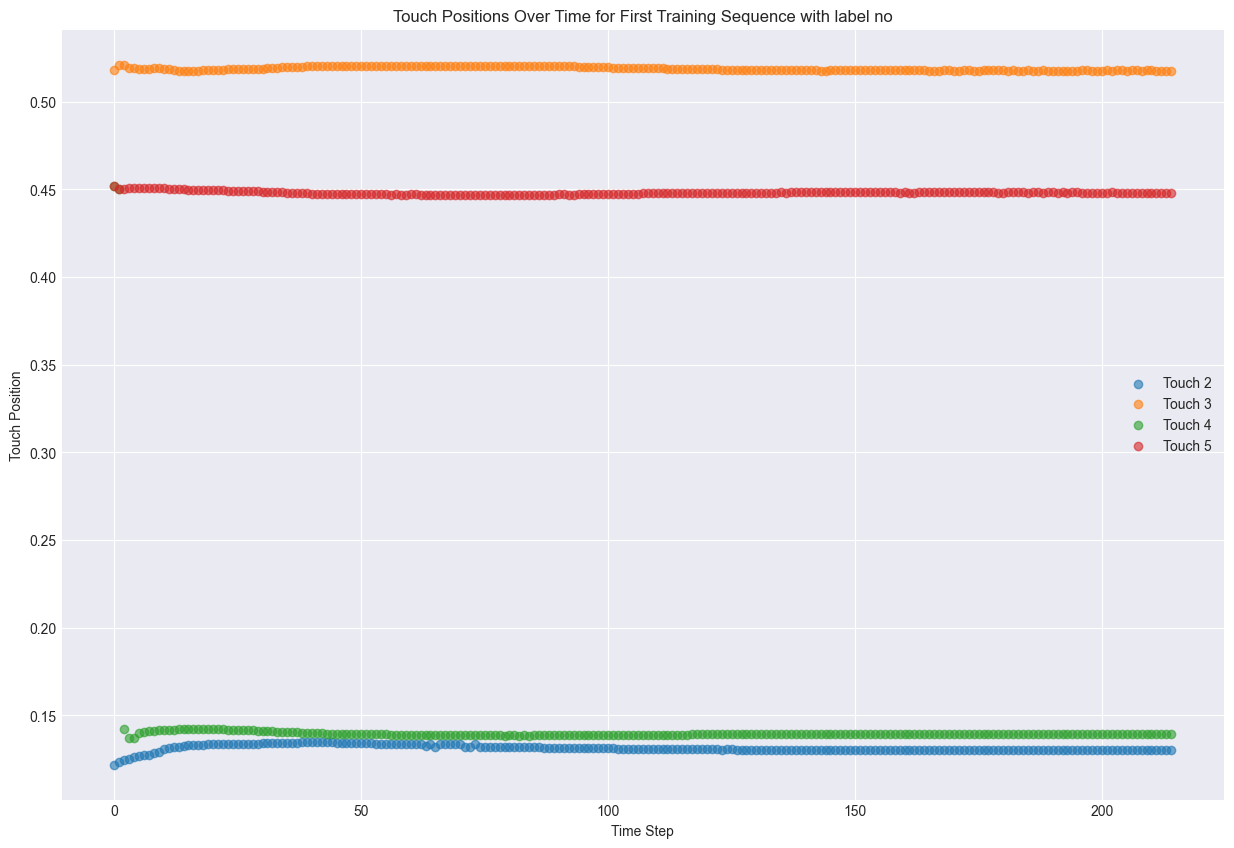

In [128]:
# Draw a graph of the first X_train sequence
plt.figure(figsize=(15, 10))
first_sequence = X_train[0]
for touch_num in range(2, 6):
    plt.scatter(
        np.arange(first_sequence.shape[0]), 
        # first_sequence[:, feature_columns.index(f"touch_{touch_num}_pos_x")], 
        # first_sequence[:, feature_columns.index(f"touch_{touch_num}_pos_y")], 
        # first_sequence[:, feature_columns.index(f"touch_{touch_num}_position")], 
        first_sequence[:, feature_columns.index(f"dist_1_{touch_num}")], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Time Step")
plt.ylabel("Touch Position")
# Print label in title
plt.title(f"Touch Positions Over Time for First Training Sequence with label {le.inverse_transform([np.argmax(y_train[0])])[0]}")
plt.legend()
plt.show()

In [129]:
# Per label, print the amount of samples in each split in one row
train_counts = pd.Series(np.argmax(y_train, axis=1)).value_counts().sort_index()
val_counts = pd.Series(np.argmax(y_val, axis=1)).value_counts().sort_index()
test_counts = pd.Series(np.argmax(y_test, axis=1)).value_counts().sort_index()
print("Label counts per split:")
for label_idx in range(num_classes):
    train_count = train_counts.get(label_idx, 0)
    val_count = val_counts.get(label_idx, 0)
    test_count = test_counts.get(label_idx, 0)
    label_name = le.classes_[label_idx]
    print(f"  {label_name}: Train={train_count}, Val={val_count}, Test={test_count}")

Label counts per split:
  no: Train=1647, Val=229, Test=300
  yes: Train=657, Val=108, Test=114


In [130]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

max_len = X_train.shape[1]
D = X_train.shape[2]
num_classes = y_train.shape[1]

model = Sequential()

# 1) Masking: ignore padded timesteps (value=0.0 from preprocessing)
model.add(Masking(mask_value=0.0, input_shape=(max_len, D)))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation="softmax"))
optimizer = Adam(learning_rate=5e-4)
model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 215, 92)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 215, 128)       │       113,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,850 (651.76 KB)

 Trainable params: 166,850 (651.76 KB)

 Non-trainable params: 0 (0.00 B)

In [131]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

batch_size = 16     # optimization knob: [16, 32, 64]
epochs = 100        # upper limit; early stopping will cut it earlier

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.7808 - loss: 0.4684 - val_accuracy: 0.9050 - val_loss: 0.3221
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.8728 - loss: 0.3041 - val_accuracy: 0.8605 - val_loss: 0.3643
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9240 - loss: 0.2144 - val_accuracy: 0.9407 - val_loss: 0.2023
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9475 - loss: 0.1509 - val_accuracy: 0.9436 - val_loss: 0.2467
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.9371 - loss: 0.1769 - val_accuracy: 0.9466 - val_loss: 0.1396
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9635 - loss: 0.1132 - val_accuracy: 0.9496 - val_loss: 0.1475
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9640 - loss: 0.1006 - val_accuracy: 0.9466 - val_loss: 0.1894
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9544 - loss: 0.1390 - 

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


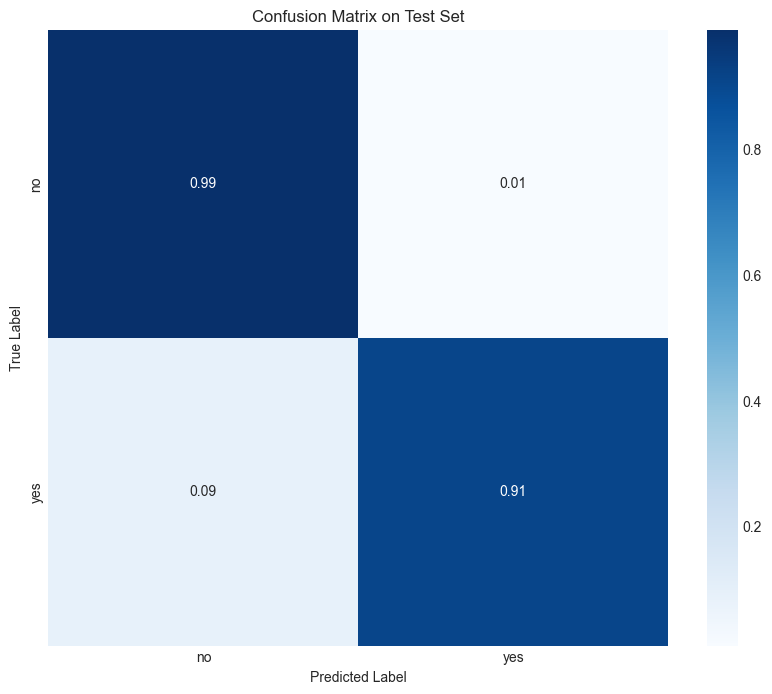

In [132]:
# Draw heatmap of confusion matrix for test set
from sklearn.metrics import confusion_matrix

y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


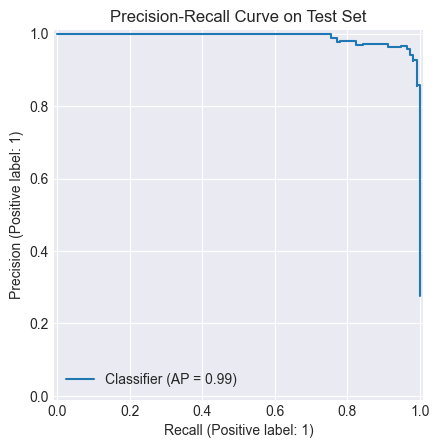

In [133]:
# draw a precision recall curve for the best model
from sklearn.metrics import PrecisionRecallDisplay
y_test_pred_probs = model.predict(X_test)
y_test_true = np.argmax(y_test, axis=1)
PrecisionRecallDisplay.from_predictions(
    y_test_true,
    y_test_pred_probs[:, 1],
)
plt.title('Precision-Recall Curve on Test Set')
plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


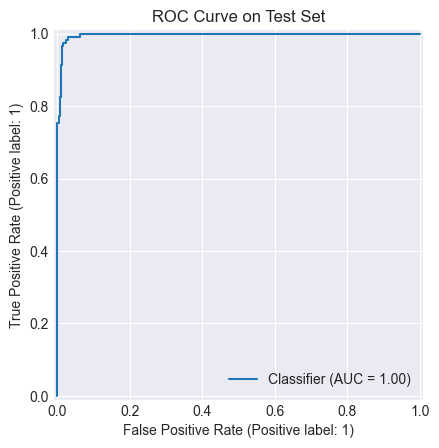

In [134]:
# draw a receiver operating characteristic (ROC) curve for the best model
from sklearn.metrics import RocCurveDisplay
y_test_pred_probs = model.predict(X_test)
y_test_true = np.argmax(y_test, axis=1)
roc_display = RocCurveDisplay.from_predictions(
    y_test_true,
    y_test_pred_probs[:, 1],
)
plt.title("ROC Curve on Test Set")
plt.show()

## Test with Szenarios

In [135]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'Tap and Hold' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'Tap and Hold' THEN 'no' ELSE 'yes' END AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,no,None


In [136]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [137]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [138]:
is_null = szenarien_df["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
szenarien_df["group_id"] = szenarien_df["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [139]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df[col] = szenarien_df[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        szenarien_df[col] = szenarien_df.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
szenarien_df['motor_angle'] = szenarien_df.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [140]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
group_id            0
dtype: int64

In [141]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
no     106236
yes      6248
Name: count, dtype: int64


In [142]:
# Print count of unique session_tasks
print(f"Unique session_task_ids in Szenarien data: {szenarien_df['session_task_id'].nunique()}")

Unique session_task_ids in Szenarien data: 227


In [143]:
# Make feature_df
szenarien_feature_df, szenarien_additional_columns = create_feature_df(szenarien_df)
szenarien_feature_columns = get_column_names(szenarien_additional_columns)

In [144]:
streams = {}        # session_task_id -> X_stream (T, D)
streams_labels = {} # session_task_id -> marker_label per frame (T,)
streams_meta = {}

for sid, sdf in szenarien_feature_df.groupby("session_task_id"):
    X_stream = sdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    meta_stream = {
        "participant_id": sdf["participant_id"].iloc[0],
        "session_task_id": sid,
        "num_samples": len(sdf),
    }
    streams[sid] = X_stream
    streams_labels[sid] = y_stream
    streams_meta[sid] = meta_stream

In [145]:
# Print number of streams
print(f"Extracted {len(streams)} streams from Szenarien data.")

Extracted 227 streams from Szenarien data.


In [146]:
max_len = max_gesture_size
step_size = 10
threshold = 0.05             # gesture confidence; tune this

print(f"Using max_len={max_len}, threshold={threshold} for online prediction.")
touch_indices = [2, 5, 8, 11, 14]  # position columns for touch_1 to touch_5

# For debug purposes draw a graph of the finger positions for each window
def predict_stream_online(X_stream, y_stream):
    did_print = 0
    T, D = X_stream.shape
    preds = []
    pred_times = []
    real_labels = []
    probas = []

    windows = []
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        window_labels = y_stream[t_start:t_end]
        if not any(label is not None for label in window_labels):
            print("Skipping window with all None labels")
            continue

        # Check if the full window is the same gesture
        unique_labels_in_window = set(label for label in window_labels if label is not None)
        # Check that the label is fully included in the window, by check if the first and last label are none
        # if (window_labels[0] is not None or window_labels[-1] is not None) and len(unique_labels_in_window) != 1:
        #     continue
        windows.append((t_start, t_end))

    for (t_start, t_end) in windows:
        window_labels = y_stream[t_start:t_end]
        window = X_stream[t_start:t_end]

        # Get the correct label for this window (most common label in the window)
        # window_labels = [label for label in y_window if label is not None]
        # if len(window_labels) == 0:
        #     continue
        most_common_label = 'no'
        # Only set the most common label to yes, if yes is included in the labels and start and end labels of the window are no
        if 'yes' in window_labels:
            most_common_label = 'yes'

        real_labels.append(most_common_label)
        
        # --- Model Prediction Logic ---
        window_batch = window[np.newaxis, ...]
        proba = model.predict(window_batch, verbose=0)[0]

        probas.append(proba)

        # print all probabilities for debug with label
        # for cls_idx, class_label in enumerate(le.classes_):
        #     ax.text(t_start, ax.get_ylim()[0] + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0]) * (cls_idx + 1), 
        #             f"{class_label}: {proba[cls_idx]:.2f}", fontsize=10, verticalalignment='bottom')

        cls_idx = np.argmax(proba)
        conf = proba[cls_idx]
        label = le.classes_[cls_idx] # if conf >= threshold else "No Gesture"

        # if label != most_common_label:
        #     print(f"Mismatch at t_start={t_start}: Predicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        #     for cls_idx_debug, class_label in enumerate(le.classes_):
        #         print(f"  {class_label}: {proba[cls_idx_debug]:.4f}")

        #     # Draw a graph of all finger positions
        #     plt.figure(figsize=(15, 10))
        #     time_axis = np.arange(window.shape[0])
        #     for touch_num in range(2, 6):
        #         plt.scatter(
        #             time_axis, 
        #             window[:, feature_columns.index(f"dist_1_{touch_num}")], 
        #             label=f"Touch {touch_num}", 
        #             alpha=0.6
        #         )
        #     plt.xlabel("Time Step")
        #     plt.ylabel("Touch Position")
        #     plt.title(f"Touch Positions Over Time for Window starting at {t_start}\nPredicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        #     plt.legend()
        #     plt.show()
        #     return
        # else:
        #     print(f"Match at t_start={t_start}: Predicted={label} (conf={conf:.2f}), Actual={most_common_label}")
        
        # Add text info to the plot itself
        # ax.text(t_start, ax.get_ylim()[1], f"Pred: {label} ({conf:.2f})", 
        #         fontsize=12, fontweight='bold', verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

        preds.append(label)
        pred_times.append(t_start)

        # did_print += 1
        # if did_print >= 5:
        #     break

    # plt.tight_layout()
    # plt.show()
    return np.array(preds), np.array(pred_times), np.array(real_labels), np.array(probas), windows


Using max_len=215, threshold=0.05 for online prediction.


In [147]:
from sklearn.metrics import confusion_matrix, classification_report

all_true = []
all_pred = []
all_probas = []
all_windows = []

# print streams keys
did_it = 0
for sid, X_stream in streams.items():
    did_it += 1
    y_stream = streams_labels[sid] 
    preds, pred_times, real_labels, probas, windows = predict_stream_online(X_stream, y_stream)

    all_true.extend(real_labels)
    all_pred.extend(preds)
    all_probas.extend(probas)
    all_windows.extend(windows)

    # Print y_stream for those that are not none
    # print(f"True labels for stream {sid}:")
    # for i in range(len(y_stream)):
    #     if y_stream[i] is not None:
    #         print(f"  Index {i}: {y_stream[i]}")

    # if did_it >= 1:
    #     break


In [148]:
# Print unique all_true and all_pred labels
all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_probas = np.array(all_probas)
all_windows = np.array(all_windows)
# Replace None with "No Gesture" in all_true
all_true = np.array([label if label is not None and label != 'No Gesture' else "Double Tap" for label in all_true])
unique_true_labels = np.unique(all_true)
unique_pred_labels = np.unique(all_pred)
print(f"Unique true labels: ({len(unique_true_labels)}) {unique_true_labels}")
print(f"Unique predicted labels: ({len(unique_pred_labels)}) {unique_pred_labels}")

Unique true labels: (2) ['no' 'yes']
Unique predicted labels: (2) ['no' 'yes']


In [149]:
# Draw a graph of the first stream and the finger positions within, also draw the bounds of the windows and color them red if the prediction is no and green if yes
# plt.figure(figsize=(15, 10))
# first_session_task_id = list(streams.keys())[0]
# first_stream = streams[first_session_task_id]
# first_meta = streams_meta[first_session_task_id]
# first_y_stream = streams_labels[first_session_task_id]
# first_windows = all_windows[0:len(first_stream) // step_size]
# first_session_df = szenarien_feature_df[szenarien_feature_df["session_task_id"] == first_session_task_id]
# for touch_num in range(1, 6):
#     plt.scatter(
#         np.arange(first_stream.shape[0]),
#         first_session_df[f"touch_{touch_num}_position"],
#         label=f"Touch {touch_num}", 
#         alpha=0.6
#     )
# # Draw window bounds
# for i, (t_start, t_end) in enumerate(first_windows):
#     if i >= len(all_pred):
#         break
#     label = all_pred[i]
#     true_label = all_true[i]
#     color = 'green' if label == 'yes' else 'red'
#     color_true = 'blue' if true_label == 'yes' else 'orange'
#     plt.axvspan(t_start, t_end, color=color, alpha=0.1 if label == 'yes' else 0)
#     plt.axvspan(t_start, t_end, color=color_true, alpha=0.03 if true_label == 'yes' else 0, linestyle='dashed', edgecolor='black')
# plt.xlabel("Time Step")
# plt.ylabel("Touch Position")
# plt.title(f"Touch Positions Over Time for First Szenarien Stream {first_session_task_id}")
# plt.legend()
# plt.show()


              precision    recall  f1-score   support

          no       0.68      0.86      0.76      5155
         yes       0.02      0.01      0.01      2156

    accuracy                           0.61      7311
   macro avg       0.35      0.44      0.38      7311
weighted avg       0.48      0.61      0.54      7311



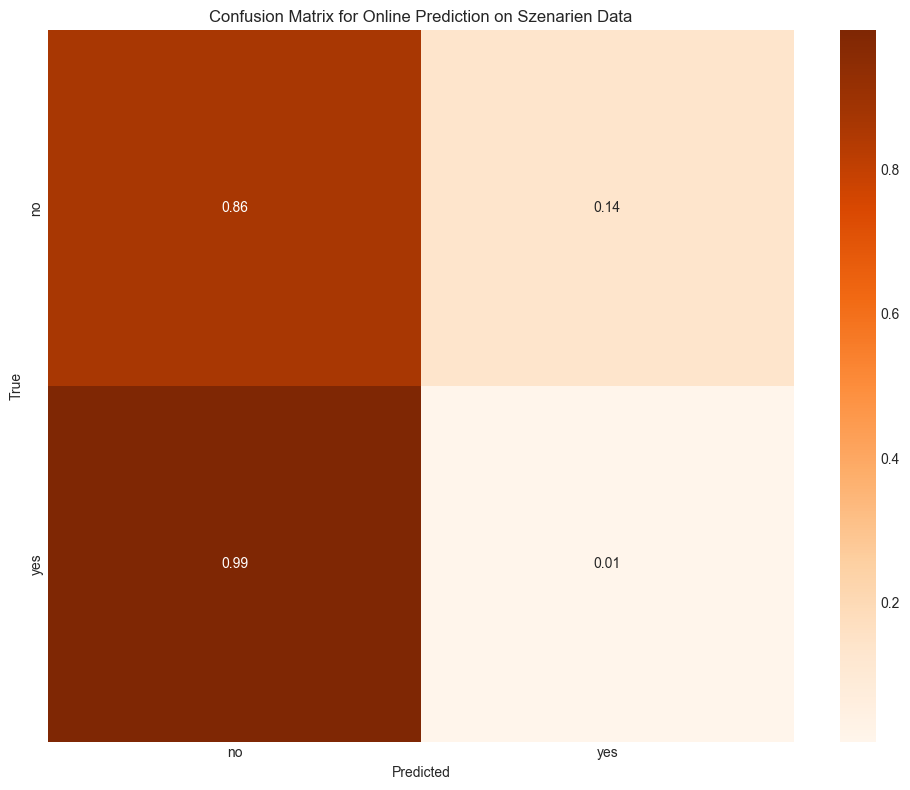

In [150]:
# Optionally restrict to known classes
# map string labels -> indices with same LabelEncoder if classes match
y_true_int = le.transform(all_true)           # if marker labels use same names
y_pred_int = le.transform(all_pred)

used_labels = np.unique(np.concatenate([y_true_int, y_pred_int]))
used_target_names = le.inverse_transform(used_labels)
print(
    classification_report(
        y_true_int,
        y_pred_int,
        labels=used_labels,
        target_names=used_target_names
    )
)

cm = confusion_matrix(y_true_int, y_pred_int, labels=range(len(le.classes_)))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Oranges"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Online Prediction on Szenarien Data")
plt.tight_layout()
plt.show()


In [151]:
# Test with szenarios, but give a whole marker_label group at once to check if the classification would work with the correct windowing strategy

# Put all group_ids in windows
windows = []
window_lables = []
meta_data = []
for gid, gdf in szenarien_feature_df.groupby("group_id"):
    # ignore if the marker_label is "No Gesture" or None
    if gdf["marker_label"].iloc[0] is None:
        continue
    X_window = gdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    windows.append(X_window)
    window_lables.append(gdf["marker_label"].iloc[0])
    meta_data.append({
        "session_task_id": gdf["session_task_id"].iloc[0],
        "participant_id": gdf["participant_id"].iloc[0],
        "group_id": gid
    })

print(f"Created {len(windows)} windows from Szenarien data for group_id prediction.")

Created 319 windows from Szenarien data for group_id prediction.


In [152]:
# Print min and max length of windows
window_lengths = [w.shape[0] for w in windows]
print(f"Window lengths: min={min(window_lengths)}, max={max(window_lengths)}")
# Print count of labels
label_counts = pd.Series(window_lables).value_counts()
print("Window label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Window lengths: min=4, max=18553
Window label counts:
  no: 187
  yes: 132


In [153]:
# Predict each window
all_window_true = []
all_window_pred = []
all_window_proba = []

for X_window, true_label in zip(windows, window_lables):
    X_batch = X_window[np.newaxis, ...]  # (1, max_len, D)
    proba = model.predict(X_batch, verbose=0)[0]
    
    all_window_proba.append(proba)

    cls_idx = np.argmax(proba)
    conf = proba[cls_idx]
    pred_label = le.classes_[cls_idx]

    all_window_true.append(true_label)
    all_window_pred.append(pred_label)
# Print unique all_window_true and all_window_pred labels
all_window_true = np.array(all_window_true)
all_window_pred = np.array(all_window_pred)
all_window_proba = np.array(all_window_proba)
unique_window_true_labels = np.unique(all_window_true)
unique_window_pred_labels = np.unique(all_window_pred)
print(f"Unique true window labels: ({len(unique_window_true_labels)}) {unique_window_true_labels}")
print(f"Unique predicted window labels: ({len(unique_window_pred_labels)}) {unique_window_pred_labels}")

Unique true window labels: (2) ['no' 'yes']
Unique predicted window labels: (2) ['no' 'yes']


              precision    recall  f1-score   support

          no       0.85      0.97      0.91       187
         yes       0.94      0.77      0.85       132

    accuracy                           0.88       319
   macro avg       0.90      0.87      0.88       319
weighted avg       0.89      0.88      0.88       319



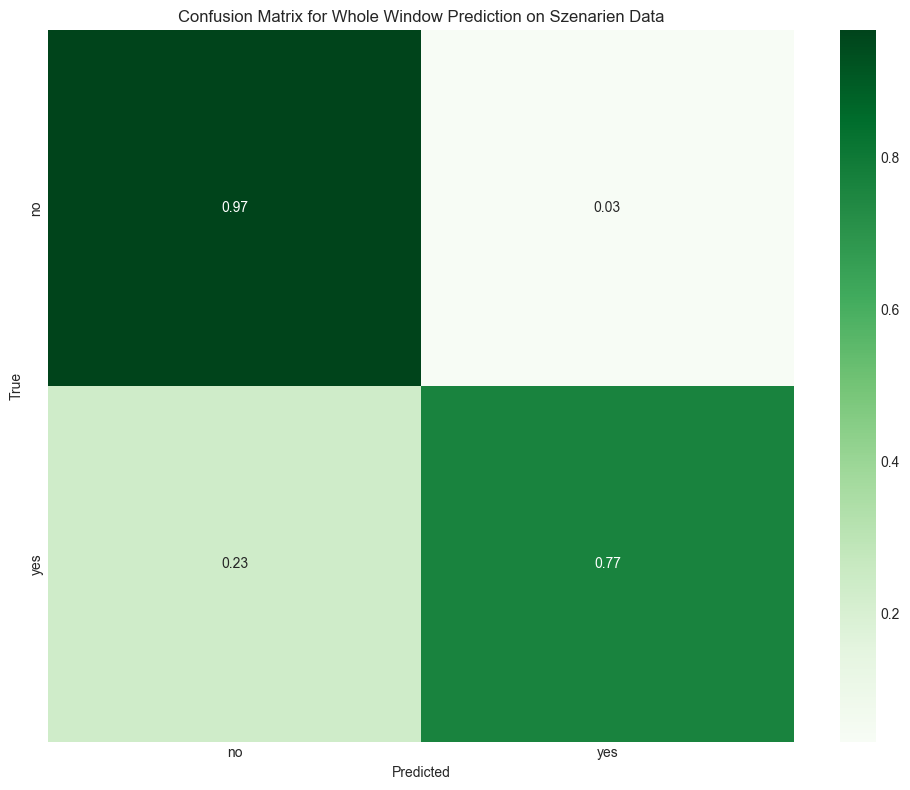

In [154]:
# Print confusion matrix and classification report for window predictions
y_window_true_int = le.transform(all_window_true)           # if marker labels use same names
y_window_pred_int = le.transform(all_window_pred)

used_labels_window = np.unique(np.concatenate([y_window_true_int, y_window_pred_int]))
used_target_names_window = le.inverse_transform(used_labels_window)
print(
    classification_report(
        y_window_true_int,
        y_window_pred_int,
        labels=used_labels_window,
        target_names=used_target_names_window
    )
)

cm_window = confusion_matrix(y_window_true_int, y_window_pred_int, labels=range(len(le.classes_)))
cm_window_norm = cm_window.astype('float') / cm_window.sum(axis=1)[:, np.newaxis]
cm_window_norm = np.nan_to_num(cm_window_norm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_window_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Greens"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Whole Window Prediction on Szenarien Data")
plt.tight_layout()
plt.show()

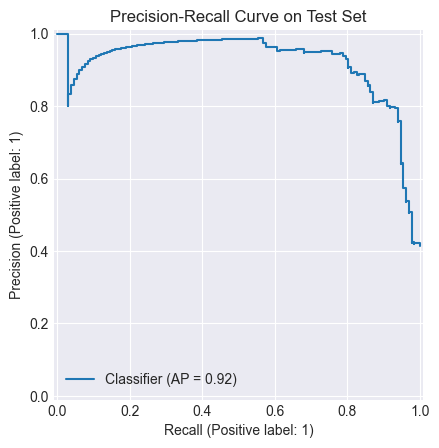

In [155]:
# draw a precision recall curve for the best model
PrecisionRecallDisplay.from_predictions(
    y_window_true_int,
    all_window_proba[:, 1],
)
plt.title('Precision-Recall Curve on Test Set')
plt.show()


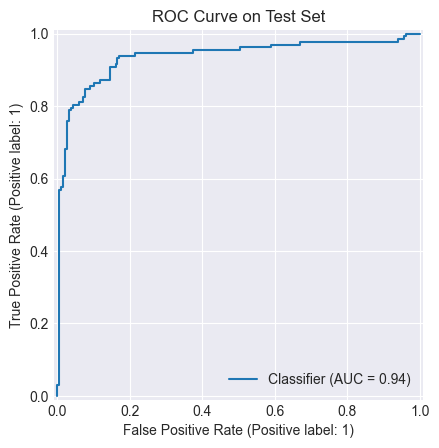

In [156]:
# draw a receiver operating characteristic (ROC) curve for the best model
roc_display = RocCurveDisplay.from_predictions(
    y_window_true_int,
    all_window_proba[:, 1],
)
plt.title("ROC Curve on Test Set")
plt.show()

In [157]:
import winsound

winsound.MessageBeep()  # system default sound